<a href="https://colab.research.google.com/github/dilarayldrmm/anemia-risk-prediction-system/blob/main/anemi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train_dataset.csv")

df.head()

,GENDER,WBC,NE#,LY#,MO#,EO#,BA#,RBC,HGB,HCT,...,TSD,FERRITTE,FOLATE,B12,All_Class,HGB_Anemia_Class,Iron_anemia_Class,Folate_anemia_class,B12_Anemia_class,Is_Anemic
0,1,8.77,5.10,2.87,0.44,0.29,0.07,4.99,10.57,35.07,...,5.156538,6.88,15.45,415.5,2,0,1,0,0,1
1,0,18.38,14.84,1.24,2.25,0.03,0.02,4.20,11.96,35.77,...,24.294099,1185.00,20.00,1654.0,1,1,0,0,0,1
2,0,6.00,4.07,1.09,0.66,0.15,0.03,3.09,9.10,27.70,...,54.966249,29.51,6.75,287.5,1,1,0,0,0,1
3,1,3.10,1.14,1.55,0.33,0.04,0.05,4.18,11.47,35.39,...,24.384251,117.90,7.49,303.9,1,1,0,0,0,1
4,0,7.53,4.84,2.17,0.33,0.15,0.05,5.22,14.75,46.03,...,36.710537,40.75,6.19,231.4,0,0,0,0,0,0


In [ ]:
print(df.columns.tolist())

['GENDER', 'WBC', 'NE#', 'LY#', 'MO#', 'EO#', 'BA#', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW', 'PLT', 'MPV', 'PCT', 'PDW', 'SD', 'SDTSD', 'TSD', 'FERRITTE', 'FOLATE', 'B12', 'All_Class', 'HGB_Anemia_Class', 'Iron_anemia_Class', 'Folate_anemia_class', 'B12_Anemia_class', 'Is_Anemic']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GENDER               8000 non-null   int64  
 1   WBC                  8000 non-null   float64
 2   NE#                  8000 non-null   float64
 3   LY#                  8000 non-null   float64
 4   MO#                  8000 non-null   float64
 5   EO#                  8000 non-null   float64
 6   BA#                  8000 non-null   float64
 7   RBC                  8000 non-null   float64
 8   HGB                  8000 non-null   float64
 9   HCT                  8000 non-null   float64
 10  MCV                  8000 non-null   float64
 11  MCH                  8000 non-null   float64
 12  MCHC                 8000 non-null   float64
 13  RDW                  8000 non-null   float64
 14  PLT                  8000 non-null   float64
 15  MPV                  8000 non-null   f

In [ ]:
df.isnull().sum()

,0
GENDER,0
WBC,0
NE#,0
LY#,0
MO#,0
EO#,0
BA#,0
RBC,0
HGB,0
HCT,0


In [ ]:
print("Toplam eksik değer sayısı:", df.isnull().sum().sum())

Toplam eksik değer sayısı: 0


In [ ]:
df.describe()

,GENDER,WBC,NE#,LY#,MO#,EO#,BA#,RBC,HGB,HCT,...,TSD,FERRITTE,FOLATE,B12,All_Class,HGB_Anemia_Class,Iron_anemia_Class,Folate_anemia_class,B12_Anemia_class,Is_Anemic
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.322625,8.164867,5.157780,2.209433,0.579393,0.151592,0.067034,4.588196,12.339245,37.811476,...,19.430424,139.304871,8.645670,403.991254,0.962750,0.090375,0.376375,0.013375,0.019875,0.500000
std,0.467510,5.172697,4.094719,2.157822,0.381145,0.173711,0.304077,0.683573,2.142786,5.713885,...,13.349821,502.791032,3.794028,553.456562,1.052379,0.286736,0.484506,0.114882,0.139579,0.500031
min,0.000000,0.570000,0.040000,0.110000,0.000000,0.000000,0.000000,1.020000,2.990000,10.300000,...,1.287001,0.500000,0.600000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,6.060000,3.390000,1.600000,0.410000,0.060000,0.038000,4.210000,11.100000,34.400000,...,9.919017,12.487500,6.100000,230.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,7.480000,4.440000,2.070000,0.530000,0.110500,0.050850,4.600000,12.300000,37.830000,...,16.856452,38.000000,7.980000,309.750000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000
75%,1.000000,9.210000,5.922500,2.590000,0.680000,0.190000,0.080000,5.000000,13.700000,41.372500,...,25.454648,111.425000,10.370000,438.700000,2.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,246.700000,197.200000,89.600000,18.510000,5.780000,24.730000,7.360000,22.450000,67.400000,...,100.000000,27332.000000,50.250000,33880.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


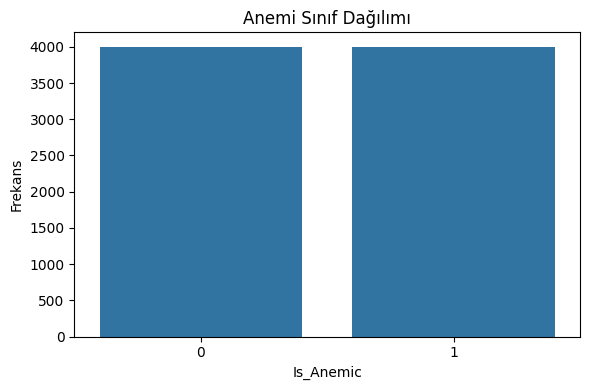

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="Is_Anemic", data=df)
plt.title("Anemi Sınıf Dağılımı")
plt.xlabel("Is_Anemic")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

In [ ]:
print(df["Is_Anemic"].value_counts())
print()
print(df["Is_Anemic"].value_counts(normalize=True) * 100)

Is_Anemic
1    4000
0    4000
Name: count, dtype: int64

Is_Anemic
1    50.0
0    50.0
Name: proportion, dtype: float64


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols.tolist())

['GENDER', 'WBC', 'NE#', 'LY#', 'MO#', 'EO#', 'BA#', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW', 'PLT', 'MPV', 'PCT', 'PDW', 'SD', 'SDTSD', 'TSD', 'FERRITTE', 'FOLATE', 'B12', 'All_Class', 'HGB_Anemia_Class', 'Iron_anemia_Class', 'Folate_anemia_class', 'B12_Anemia_class', 'Is_Anemic']


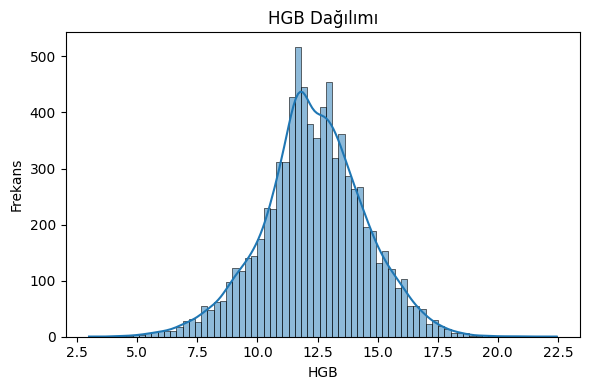

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["HGB"], kde=True)
plt.title("HGB Dağılımı")
plt.xlabel("HGB")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

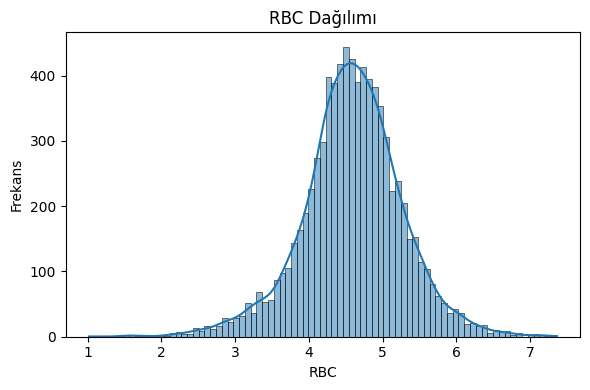

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["RBC"], kde=True)
plt.title("RBC Dağılımı")
plt.xlabel("RBC")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

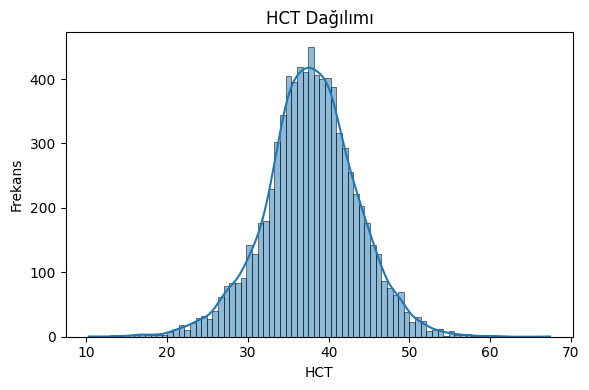

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["HCT"], kde=True)
plt.title("HCT Dağılımı")
plt.xlabel("HCT")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

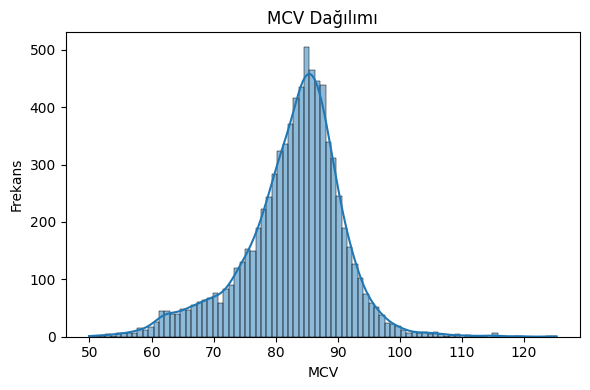

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["MCV"], kde=True)
plt.title("MCV Dağılımı")
plt.xlabel("MCV")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

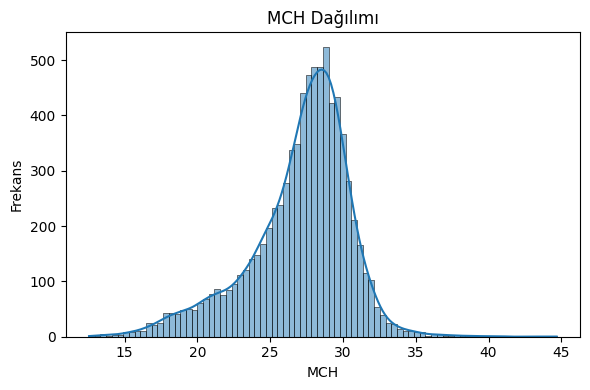

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["MCH"], kde=True)
plt.title("MCH Dağılımı")
plt.xlabel("MCH")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

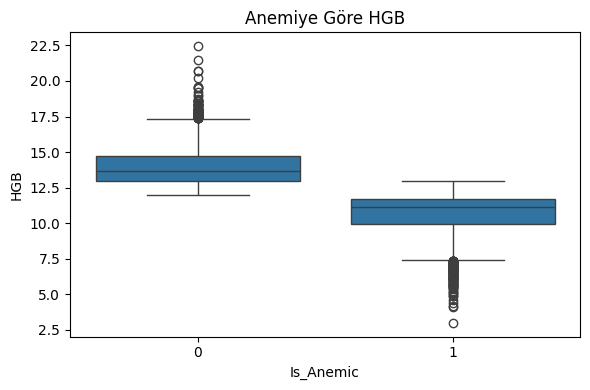

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Is_Anemic", y="HGB", data=df)
plt.title("Anemiye Göre HGB")
plt.xlabel("Is_Anemic")
plt.ylabel("HGB")
plt.tight_layout()
plt.show()

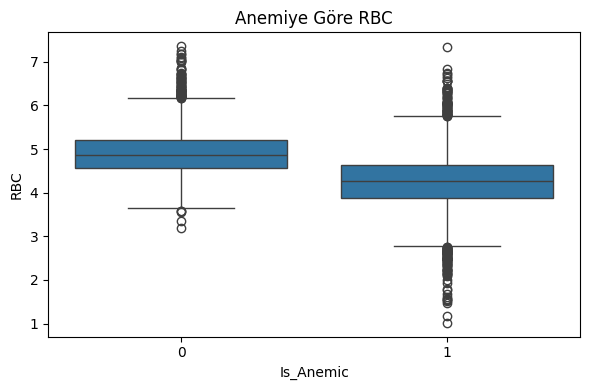

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Is_Anemic", y="RBC", data=df)
plt.title("Anemiye Göre RBC")
plt.xlabel("Is_Anemic")
plt.ylabel("RBC")
plt.tight_layout()
plt.show()

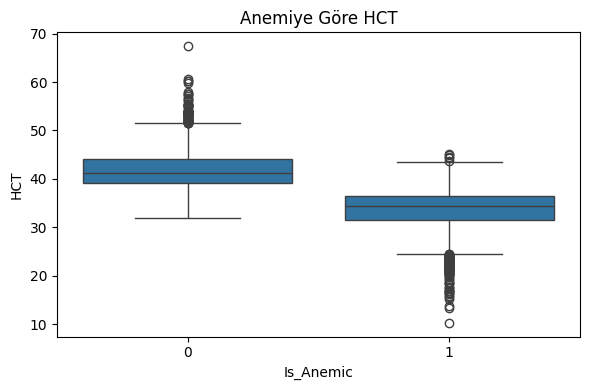

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Is_Anemic", y="HCT", data=df)
plt.title("Anemiye Göre HCT")
plt.xlabel("Is_Anemic")
plt.ylabel("HCT")
plt.tight_layout()
plt.show()

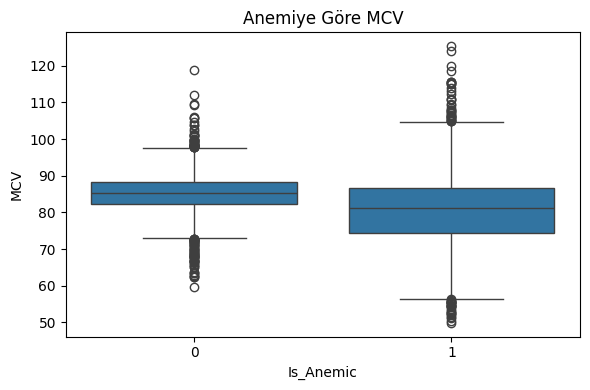

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Is_Anemic", y="MCV", data=df)
plt.title("Anemiye Göre MCV")
plt.xlabel("Is_Anemic")
plt.ylabel("MCV")
plt.tight_layout()
plt.show()

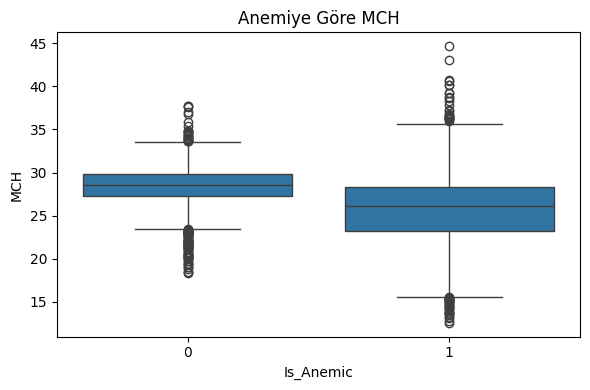

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Is_Anemic", y="MCH", data=df)
plt.title("Anemiye Göre MCH")
plt.xlabel("Is_Anemic")
plt.ylabel("MCH")
plt.tight_layout()
plt.show()

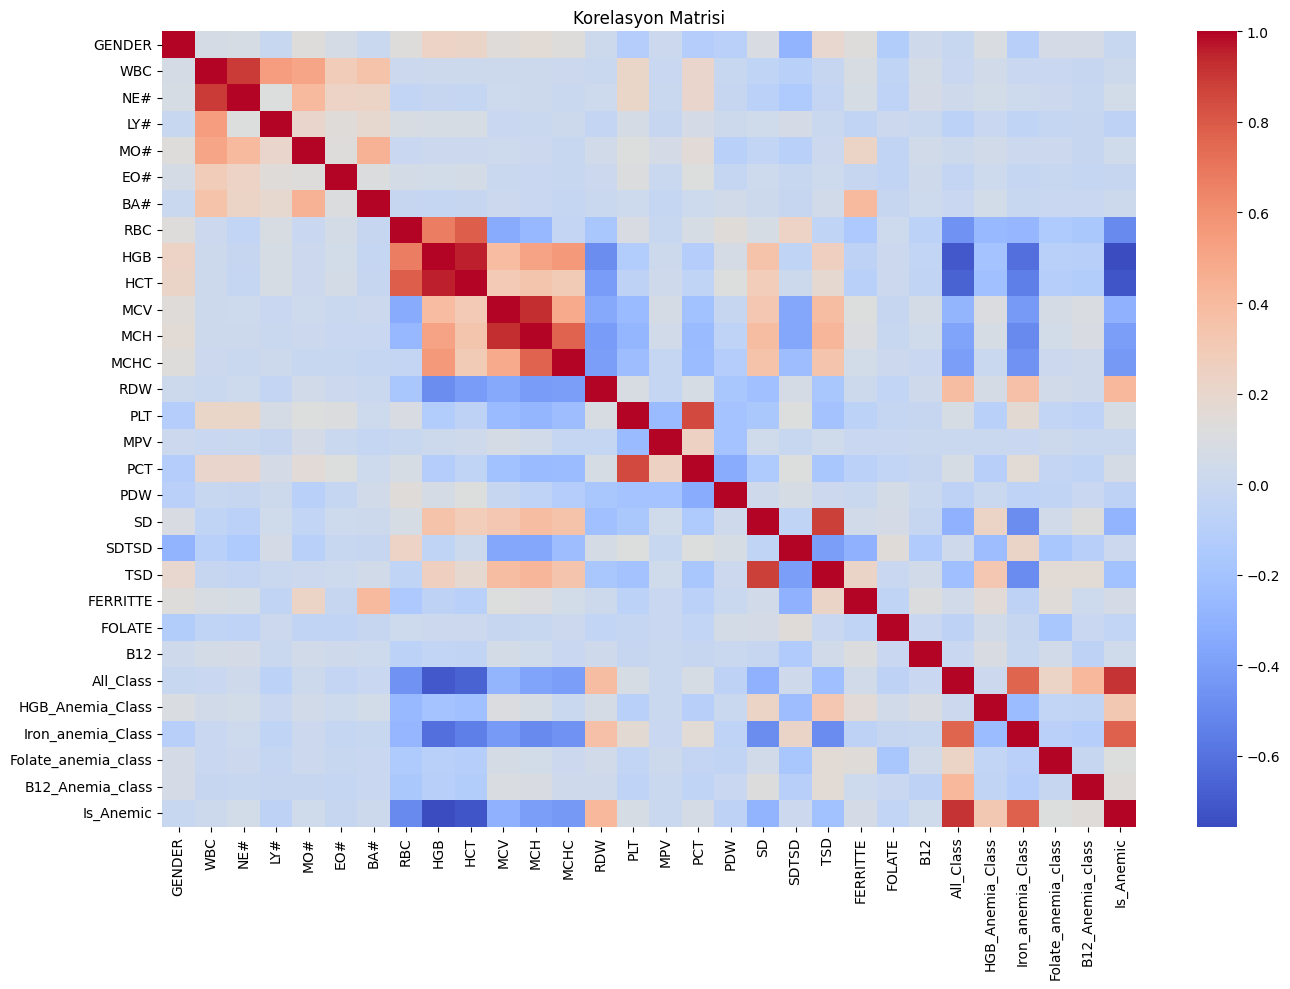

In [ ]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

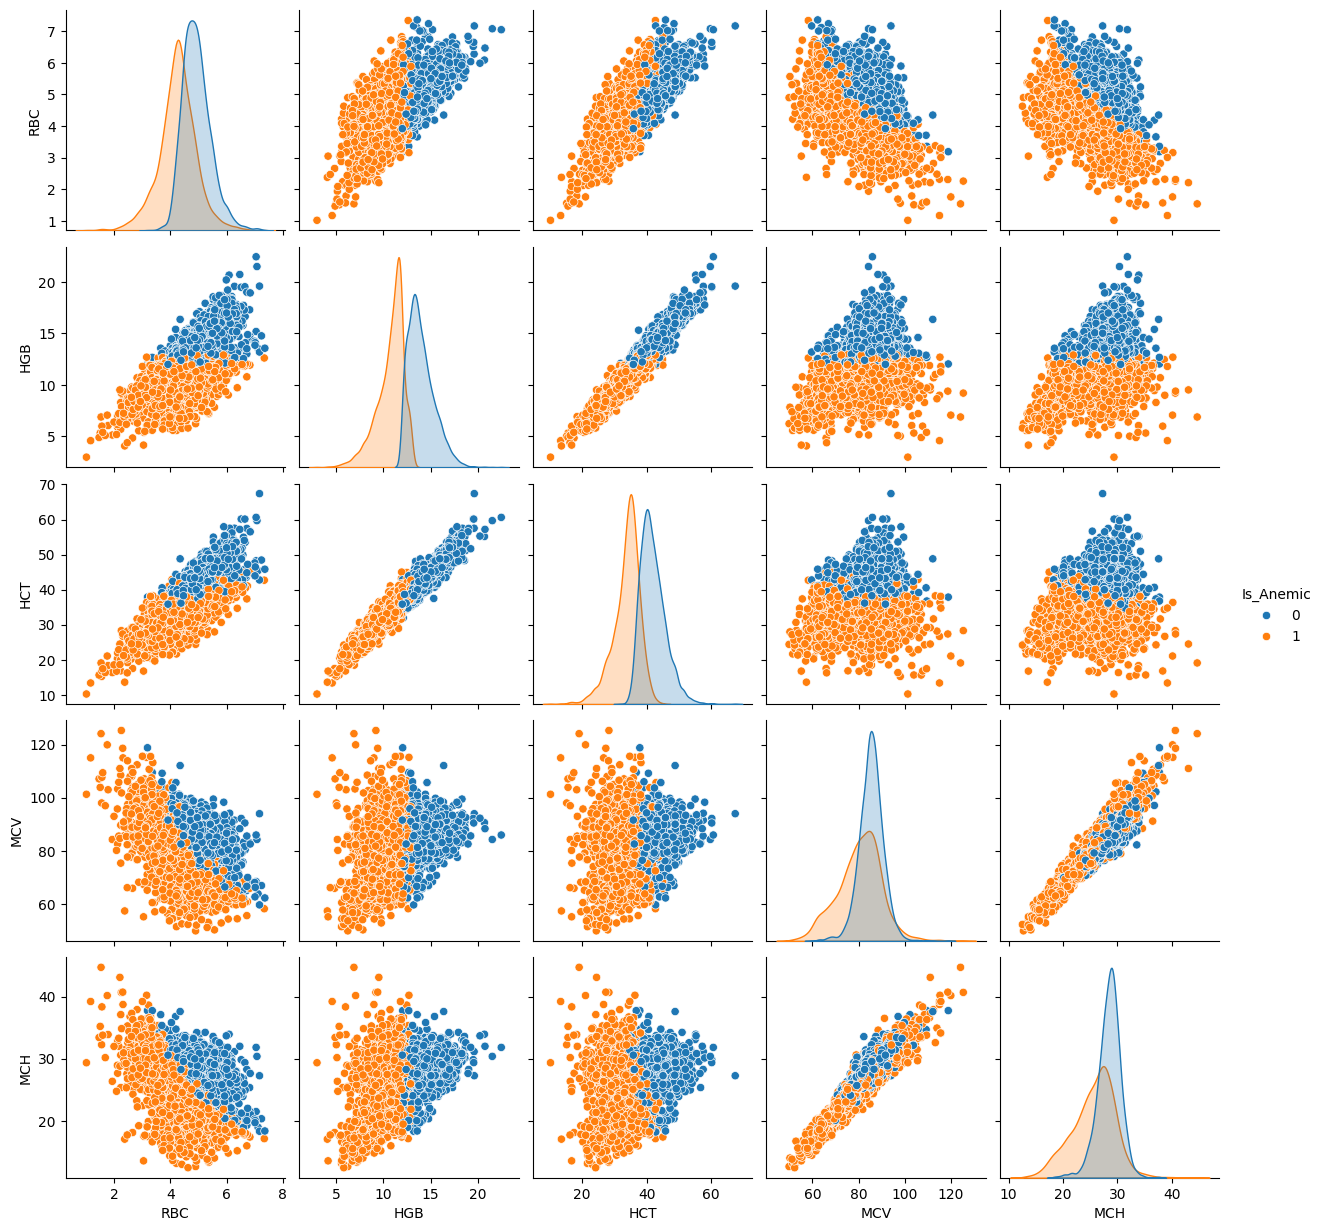

In [ ]:
selected_cols = ["RBC", "HGB", "HCT", "MCV", "MCH", "Is_Anemic"]
sns.pairplot(df[selected_cols], hue="Is_Anemic")
plt.show()

In [ ]:
group_mean = df.groupby("Is_Anemic")[["RBC", "HGB", "HCT", "MCV", "MCH"]].mean()
print(group_mean)

                RBC       HGB        HCT        MCV        MCH
Is_Anemic                                                     
0          4.926929  13.95885  41.900340  85.302095  28.430690
1          4.249462  10.71964  33.722613  80.344765  25.633917


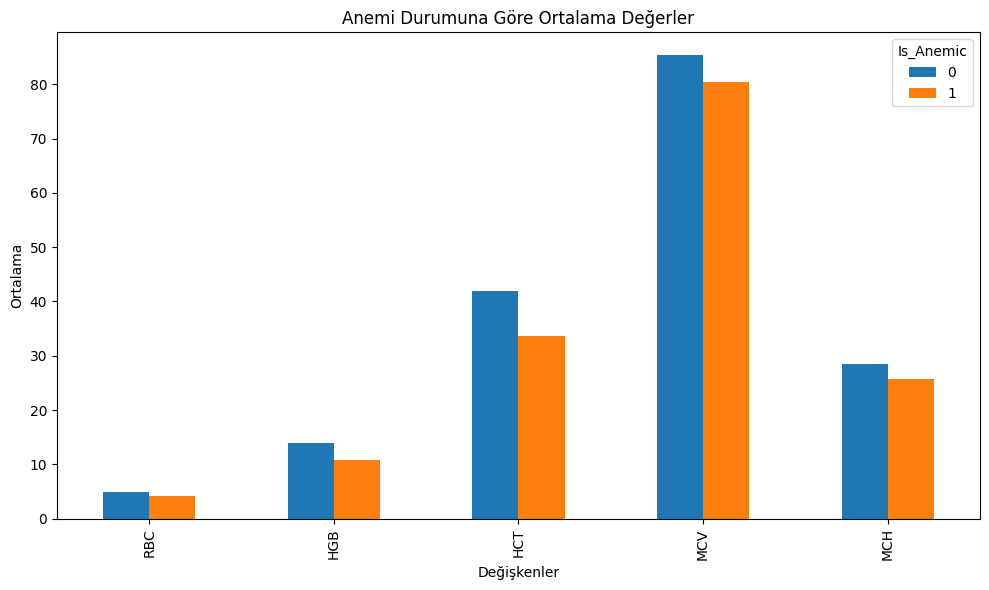

In [ ]:
group_mean.T.plot(kind="bar", figsize=(10,6))
plt.title("Anemi Durumuna Göre Ortalama Değerler")
plt.ylabel("Ortalama")
plt.xlabel("Değişkenler")
plt.tight_layout()
plt.show()

In [ ]:
import shutil

shutil.copy("/content/drive/MyDrive/Colab Notebooks/anemi.ipynb", "/content/anemi.ipynb")

!jupyter nbconvert --to html "/content/anemi.ipynb"

[NbConvertApp] Converting notebook /content/anemi.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 12 image(s).
[NbConvertApp] Writing 720051 bytes to /content/anemi.html
